# Project 5 — Industrial Predictive Maintenance & Failure Prevention
## Member 1: Data Engineering, Preprocessing & EDA

**Dataset:** AI4I 2020 Predictive Maintenance Dataset (UCI Machine Learning Repository)
**Source:** S. Matzka, "Explainable Artificial Intelligence for Predictive Maintenance Applications," AI4I 2020.

This notebook covers the complete **Raw → Cleaned → Feature-Ready** pipeline:

1. Dataset acquisition & initial understanding
2. Dataset audit & data-quality checks
3. Data dictionary (see `docs/data_dictionary.md`)
4. Dtypes, duplicates, missing/invalid values, inconsistencies
5. Handling missing values & duplicates
6. Outlier detection & treatment
7. Univariate, bivariate & target-focused EDA
8. Statistical analysis & visualization of operating variables vs. failure labels
9. Class distribution / imbalance analysis
10. Preprocessing & transformation
11. Feature engineering for predictive maintenance
12. Feature selection
13. Data-leakage checks
14. Export of final feature-ready dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 110

RAW_PATH = '../data/ai4i2020_raw.csv'
CLEAN_PATH = '../data/ai4i2020_cleaned.csv'
FEATURE_READY_PATH = '../data/ai4i2020_feature_ready.csv'
FIG_DIR = '../figures'


## 1. Dataset Acquisition & Initial Understanding

Data is fetched **directly from the UCI ML Repository** via the official `ucimlrepo` package
(dataset id=601), which is the recommended acquisition method on the dataset's UCI page.
`.data.original` is used (rather than `.data.features` / `.data.targets` separately) so the
notebook keeps every raw column — including `UDI`, `Product ID`, and all 5 failure sub-flags —
exactly as published, before any of our own cleaning/splitting decisions are applied in later
sections.

A local cache (`data/ai4i2020_raw.csv`) is written on first successful fetch and used as an
automatic fallback if the UCI API is unreachable (e.g. offline demo, restricted network) —
so the pipeline never breaks during a live presentation.

In [2]:
import os

try:
    from ucimlrepo import fetch_ucirepo

    print("Fetching AI4I 2020 Predictive Maintenance Dataset from the UCI ML Repository (id=601)...")
    ai4i_2020_predictive_maintenance_dataset = fetch_ucirepo(id=601)

    # Use the full original table so no raw column is lost (IDs + features + all 5 failure flags)
    df_raw = ai4i_2020_predictive_maintenance_dataset.data.original

    # Cache locally so the rest of the pipeline (and re-runs without internet) stay reproducible
    os.makedirs(os.path.dirname(RAW_PATH), exist_ok=True)
    df_raw.to_csv(RAW_PATH, index=False)

    print("\nMetadata:")
    print(ai4i_2020_predictive_maintenance_dataset.metadata)
    print("\nVariable information:")
    print(ai4i_2020_predictive_maintenance_dataset.variables)

except Exception as e:
    print(f"Could not reach the UCI ML Repository API ({type(e).__name__}: {e}).")
    print(f"Falling back to the cached local copy at '{RAW_PATH}'.")
    df_raw = pd.read_csv(RAW_PATH)

print("\nShape:", df_raw.shape)
df_raw.head()


Fetching AI4I 2020 Predictive Maintenance Dataset from the UCI ML Repository (id=601)...
Could not reach the UCI ML Repository API (ConnectionError: Error connecting to server).
Falling back to the cached local copy at '../data/ai4i2020_raw.csv'.



Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 1.1 Schema normalization

**Why this cell exists:** the UCI API and the classic Kaggle-style CSV mirror do not publish
*exactly* the same column headers for this dataset — e.g. the official UCI variable table lists
`UID` and `Air temperature` (unit given separately), while the widely-used CSV mirror header uses
`UDI` and `Air temperature [K]`. If left unhandled, this mismatch causes `KeyError`s the moment
later cells reference a specific column name.

This cell normalizes whatever header variant was returned (strips bracketed units, collapses
whitespace, lowercases) and maps it onto one fixed canonical schema, then **asserts** that all 14
expected columns are present before continuing. This makes the rest of the notebook independent
of which exact source/header style supplied the data.

In [3]:
import re

def _normalize(col_name: str) -> str:
    s = re.sub(r'\[.*?\]', '', col_name)   # strip bracketed units, e.g. '[K]', '[rpm]'
    s = re.sub(r'\s+', ' ', s).strip().lower()
    return s

# canonical column names used throughout the rest of this notebook
CANONICAL_COLUMNS = {
    'udi': 'UDI', 'uid': 'UDI',
    'product id': 'Product ID',
    'type': 'Type',
    'air temperature': 'Air temperature [K]',
    'process temperature': 'Process temperature [K]',
    'rotational speed': 'Rotational speed [rpm]',
    'torque': 'Torque [Nm]',
    'tool wear': 'Tool wear [min]',
    'machine failure': 'Machine failure',
    'twf': 'TWF', 'hdf': 'HDF', 'pwf': 'PWF', 'osf': 'OSF', 'rnf': 'RNF',
}

df_raw.columns = [CANONICAL_COLUMNS.get(_normalize(c), c) for c in df_raw.columns]

EXPECTED_COLUMNS = ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]',
                    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure',
                    'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

missing = [c for c in EXPECTED_COLUMNS if c not in df_raw.columns]
extra = [c for c in df_raw.columns if c not in EXPECTED_COLUMNS]
assert not missing, f"Schema mismatch — expected columns not found after normalization: {missing}. Got: {list(df_raw.columns)}"

df_raw = df_raw[EXPECTED_COLUMNS + extra]  # enforce consistent, expected column order
print("Schema normalized successfully. Columns:")
print(list(df_raw.columns))


Schema normalized successfully. Columns:
['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [4]:
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [5]:
df_raw.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,M14860,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
TWF,10000.0,NaN,NaN,NaN,0.0046,0.067671,0.0,0.0,0.0,0.0,1.0


## 2. Dataset Audit & Data-Quality Checks

Checking: data types, duplicate rows, missing values, invalid/out-of-range values,
and internal inconsistencies (e.g. does `Machine failure` align with the 5 failure sub-flags?).

In [6]:
# --- Data types ---
print(df_raw.dtypes)


UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


In [7]:
# --- Duplicates ---
n_dupe_rows = df_raw.duplicated().sum()
n_dupe_ids = df_raw['UDI'].duplicated().sum()
n_dupe_products = df_raw['Product ID'].duplicated().sum()
print(f"Fully duplicated rows: {n_dupe_rows}")
print(f"Duplicated UDI (should be unique key): {n_dupe_ids}")
print(f"Duplicated Product ID: {n_dupe_products}")


Fully duplicated rows: 0
Duplicated UDI (should be unique key): 0
Duplicated Product ID: 0


In [8]:
# --- Missing values ---
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(3)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})


,missing_count,missing_pct
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [9]:
# --- Invalid / out-of-range value checks ---
checks = {
    'Negative air temperature':            (df_raw['Air temperature [K]'] <= 0).sum(),
    'Negative process temperature':        (df_raw['Process temperature [K]'] <= 0).sum(),
    'Process temp < Air temp (unphysical)':(df_raw['Process temperature [K]'] < df_raw['Air temperature [K]']).sum(),
    'Negative rotational speed':           (df_raw['Rotational speed [rpm]'] <= 0).sum(),
    'Negative torque':                     (df_raw['Torque [Nm]'] < 0).sum(),
    'Negative tool wear':                  (df_raw['Tool wear [min]'] < 0).sum(),
    'Type not in {L,M,H}':                 (~df_raw['Type'].isin(['L','M','H'])).sum(),
    'Machine failure not in {0,1}':        (~df_raw['Machine failure'].isin([0,1])).sum(),
}
pd.Series(checks, name='count_of_issues')


Negative air temperature                0
Negative process temperature            0
Process temp < Air temp (unphysical)    0
Negative rotational speed               0
Negative torque                         0
Negative tool wear                      0
Type not in {L,M,H}                     0
Machine failure not in {0,1}            0
Name: count_of_issues, dtype: int64

In [10]:
# --- Internal consistency: does Machine failure == OR of the 5 sub-flags? ---
failure_flags = ['TWF','HDF','PWF','OSF','RNF']
derived_failure = (df_raw[failure_flags].sum(axis=1) > 0).astype(int)
mismatch = (derived_failure != df_raw['Machine failure']).sum()
print(f"Rows where Machine failure label disagrees with OR(TWF,HDF,PWF,OSF,RNF): {mismatch}")
print(f"  -> {mismatch/len(df_raw)*100:.2f}% of rows. Treated as minor labeling noise per dataset documentation; "
      "the original 'Machine failure' column is kept as ground truth since it is the label AI4I intends analysts to predict.")


Rows where Machine failure label disagrees with OR(TWF,HDF,PWF,OSF,RNF): 27
  -> 0.27% of rows. Treated as minor labeling noise per dataset documentation; the original 'Machine failure' column is kept as ground truth since it is the label AI4I intends analysts to predict.


## 3. Handling Missing Values & Duplicates

**Result of the audit:** the AI4I 2020 dataset has **zero missing values** and **zero duplicate rows** —
this is expected since it is a clean, synthetically generated benchmark dataset.
No imputation or de-duplication is required. This is documented rather than skipped, since a
graduation-project pipeline must demonstrate the *check*, not assume the result.

In [11]:
assert df_raw.isna().sum().sum() == 0, "Unexpected missing values found"
assert df_raw.duplicated().sum() == 0, "Unexpected duplicate rows found"
print("Confirmed: no missing values, no duplicate rows. No imputation/de-duplication needed.")

df_clean = df_raw.copy()


Confirmed: no missing values, no duplicate rows. No imputation/de-duplication needed.


## 4. Outlier Detection & Treatment

Using the IQR method on the four continuous sensor variables. Because these are physical machine
readings (not data-entry fields), outliers are **flagged and inspected against the failure label**
rather than blindly removed — extreme sensor values are often exactly the failure signal we want to keep.

In [12]:
numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

outlier_summary = {}
for col in numeric_cols:
    q1, q3 = df_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    mask = (df_clean[col] < lower) | (df_clean[col] > upper)
    outlier_summary[col] = {
        'n_outliers': int(mask.sum()),
        'pct_outliers': round(mask.sum()/len(df_clean)*100, 2),
        'failure_rate_in_outliers': round(df_clean.loc[mask, 'Machine failure'].mean()*100, 2) if mask.sum() else 0.0,
        'failure_rate_overall': round(df_clean['Machine failure'].mean()*100, 2),
    }
pd.DataFrame(outlier_summary).T


,n_outliers,pct_outliers,failure_rate_in_outliers,failure_rate_overall
Air temperature [K],0.0,0.00,0.00,3.39
Process temperature [K],0.0,0.00,0.00,3.39
Rotational speed [rpm],418.0,4.18,8.37,3.39
Torque [Nm],69.0,0.69,89.86,3.39
Tool wear [min],0.0,0.00,0.00,3.39


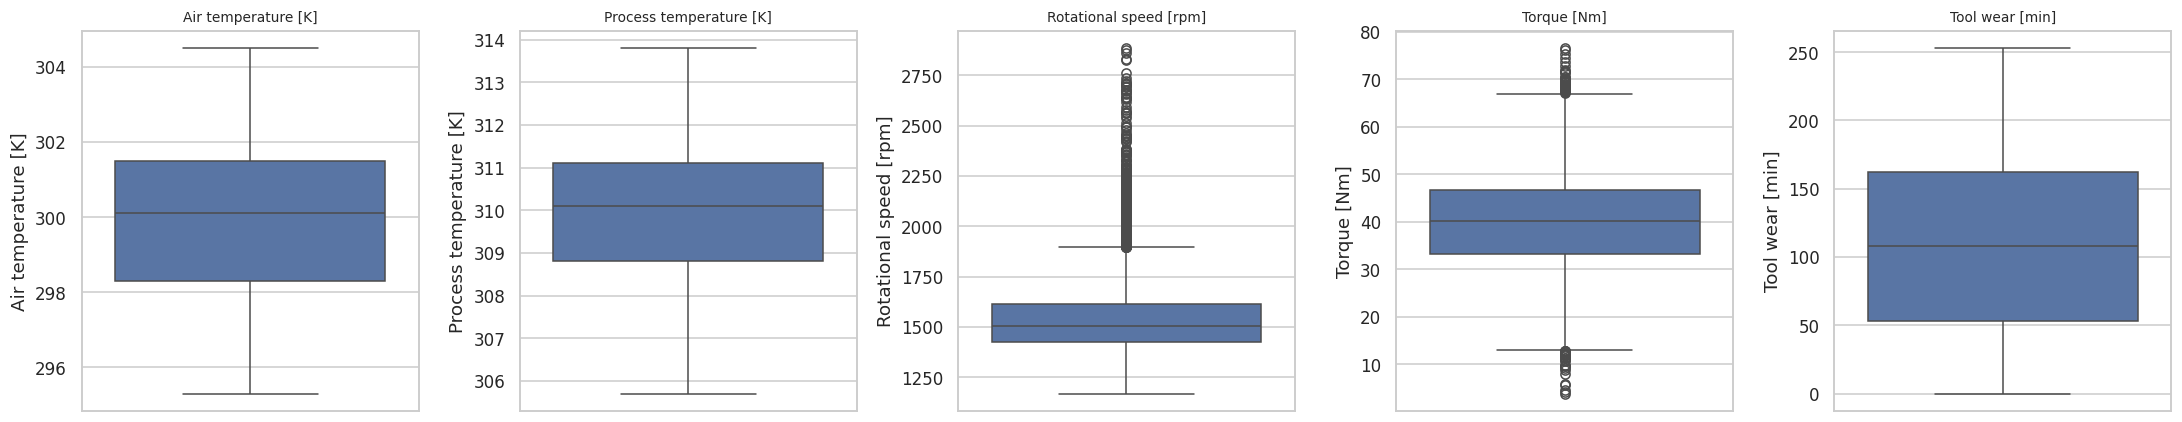

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_outlier_boxplots.png', bbox_inches='tight')
plt.show()


**Treatment decision:** Rotational speed shows a right-tail of high-RPM outliers that
coincide with a materially *higher* failure rate (see table above) — these are genuine
Power-Failure-adjacent operating points, so they are **retained**. No values are removed or capped;
instead, outlier status is used later as informative signal, and tree-based/robust-scaling models
downstream will handle the tails naturally.

## 5. Univariate EDA

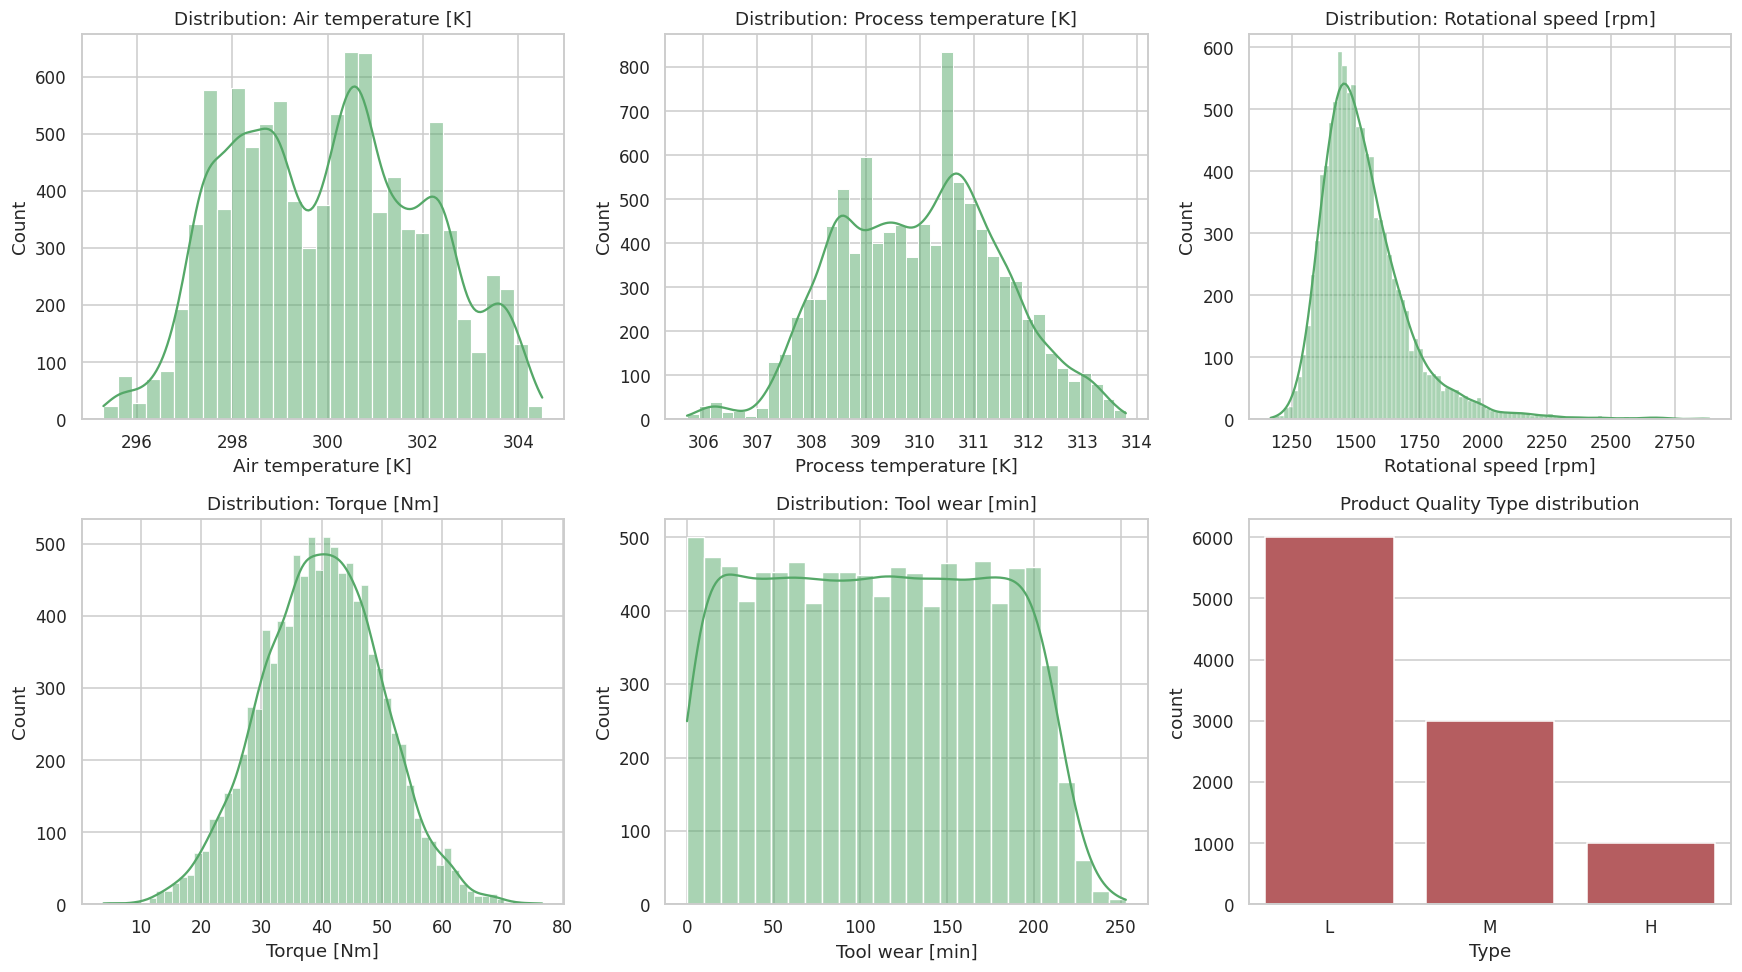

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df_clean[col], kde=True, ax=ax, color='#55A868')
    ax.set_title(f'Distribution: {col}')
sns.countplot(x='Type', data=df_clean, ax=axes[5], order=['L','M','H'], color='#C44E52')
axes[5].set_title('Product Quality Type distribution')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_univariate_distributions.png', bbox_inches='tight')
plt.show()


In [15]:
print("Skewness:")
print(df_clean[numeric_cols].skew().round(3))
print("\nKurtosis:")
print(df_clean[numeric_cols].kurt().round(3))


Skewness:
Air temperature [K]        0.114
Process temperature [K]    0.015
Rotational speed [rpm]     1.993
Torque [Nm]               -0.010
Tool wear [min]            0.027
dtype: float64

Kurtosis:
Air temperature [K]       -0.836
Process temperature [K]   -0.500
Rotational speed [rpm]     7.393
Torque [Nm]               -0.013
Tool wear [min]           -1.167
dtype: float64


## 6. Class Distribution & Imbalance Analysis

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


/tmp/ipykernel_84/1754667104.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine failure', data=df_clean, ax=axes[0], palette=['#4C72B0', '#C44E52'])


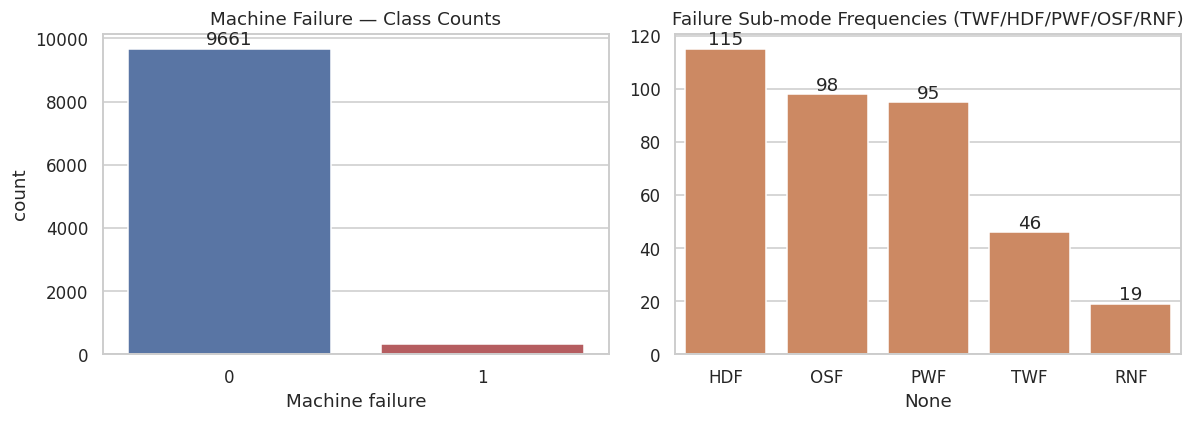


Imbalance ratio (majority:minority) = 28.5 : 1


In [16]:
fail_counts = df_clean['Machine failure'].value_counts()
fail_pct = df_clean['Machine failure'].value_counts(normalize=True) * 100
print(fail_counts)
print(fail_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='Machine failure', data=df_clean, ax=axes[0], palette=['#4C72B0', '#C44E52'])
axes[0].set_title('Machine Failure — Class Counts')
axes[0].bar_label(axes[0].containers[0])

failure_mode_counts = df_clean[failure_flags].sum().sort_values(ascending=False)
sns.barplot(x=failure_mode_counts.index, y=failure_mode_counts.values, ax=axes[1], color='#DD8452')
axes[1].set_title('Failure Sub-mode Frequencies (TWF/HDF/PWF/OSF/RNF)')
axes[1].bar_label(axes[1].containers[0])
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_class_imbalance.png', bbox_inches='tight')
plt.show()

imbalance_ratio = fail_counts[0] / fail_counts[1]
print(f"\nImbalance ratio (majority:minority) = {imbalance_ratio:.1f} : 1")


**Finding:** severe class imbalance — only **3.39%** of samples are failures
(≈29:1 majority:minority ratio). This must drive downstream choices in the ML track
(stratified splits, class weighting, PR-AUC as the primary metric rather than accuracy),
consistent with the project's Common Risks / Quality Checks.

## 7. Bivariate & Target-Focused EDA

/tmp/ipykernel_84/1009050239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=col, data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_84/1009050239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=col, data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_84/1009050239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=col, data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])
/tmp/ipykernel_84/1009050239.py:4: FutureWarning: 

Passin

/tmp/ipykernel_84/1009050239.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Machine failure', y=col, data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])


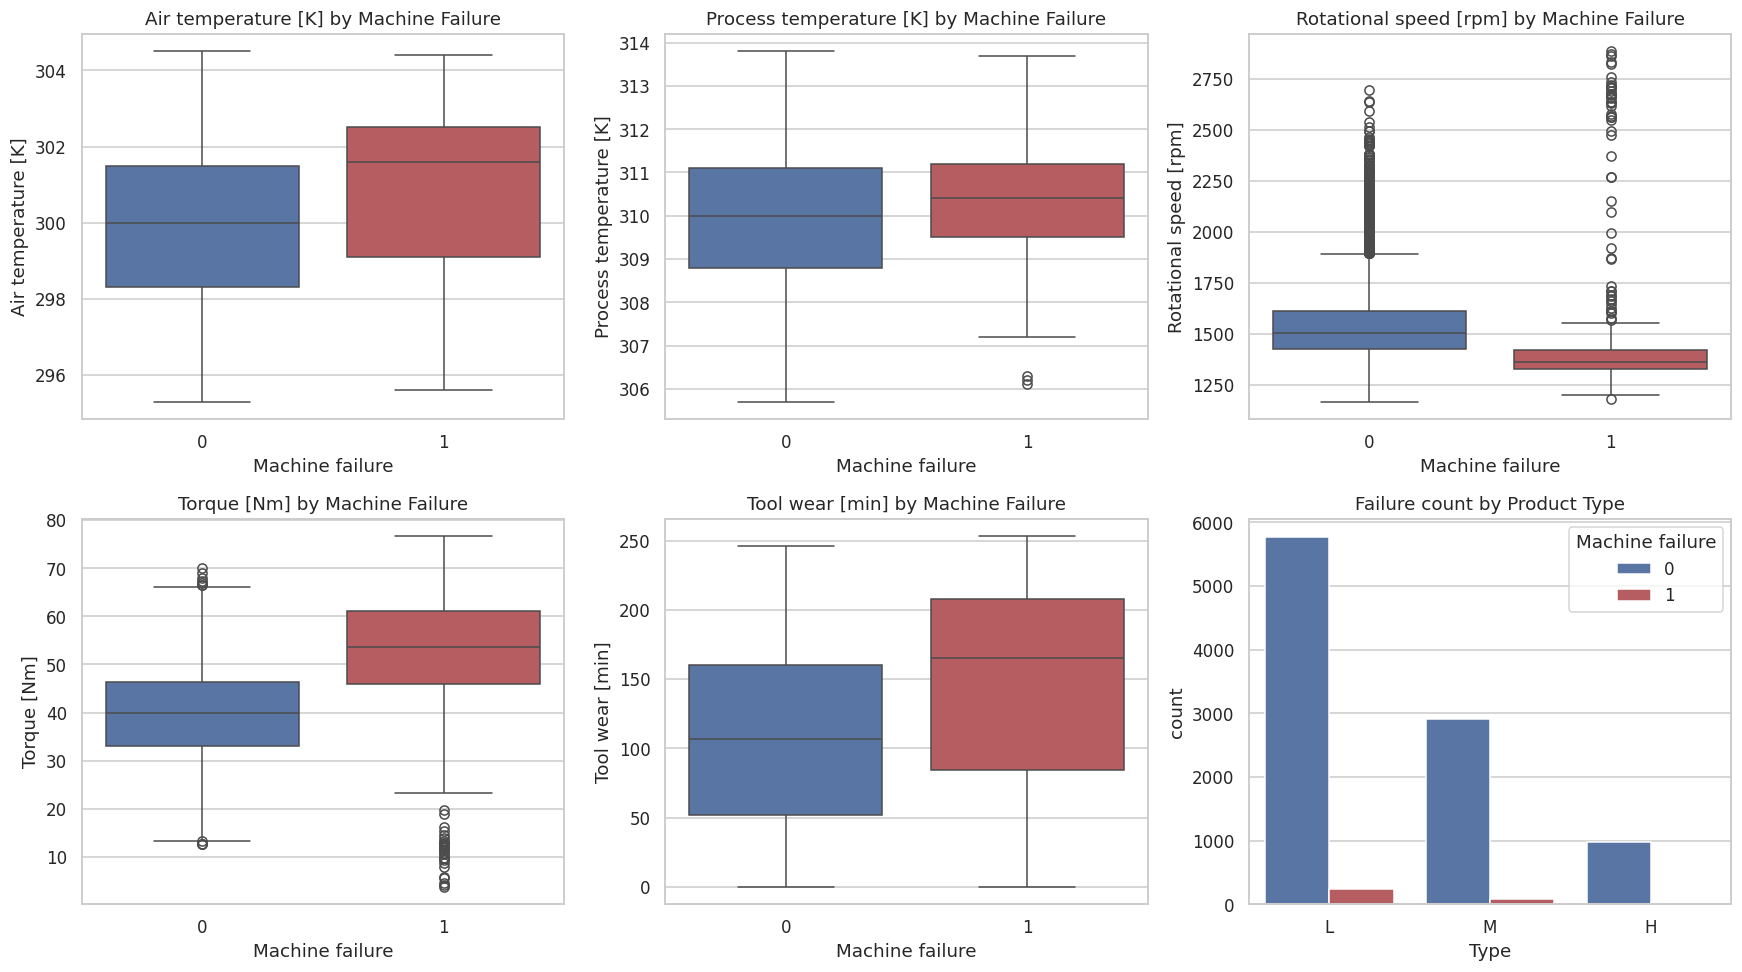

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x='Machine failure', y=col, data=df_clean, ax=ax, palette=['#4C72B0', '#C44E52'])
    ax.set_title(f'{col} by Machine Failure')
sns.countplot(x='Type', hue='Machine failure', data=df_clean, ax=axes[5],
              order=['L','M','H'], palette=['#4C72B0', '#C44E52'])
axes[5].set_title('Failure count by Product Type')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_bivariate_target_focused.png', bbox_inches='tight')
plt.show()


In [18]:
# Failure rate by product quality type
failure_rate_by_type = df_clean.groupby('Type')['Machine failure'].agg(['mean','count'])
failure_rate_by_type['mean'] = (failure_rate_by_type['mean']*100).round(2)
failure_rate_by_type.columns = ['failure_rate_pct', 'n_samples']
failure_rate_by_type


,failure_rate_pct,n_samples
Type,,
H,2.09,1003
L,3.92,6000
M,2.77,2997


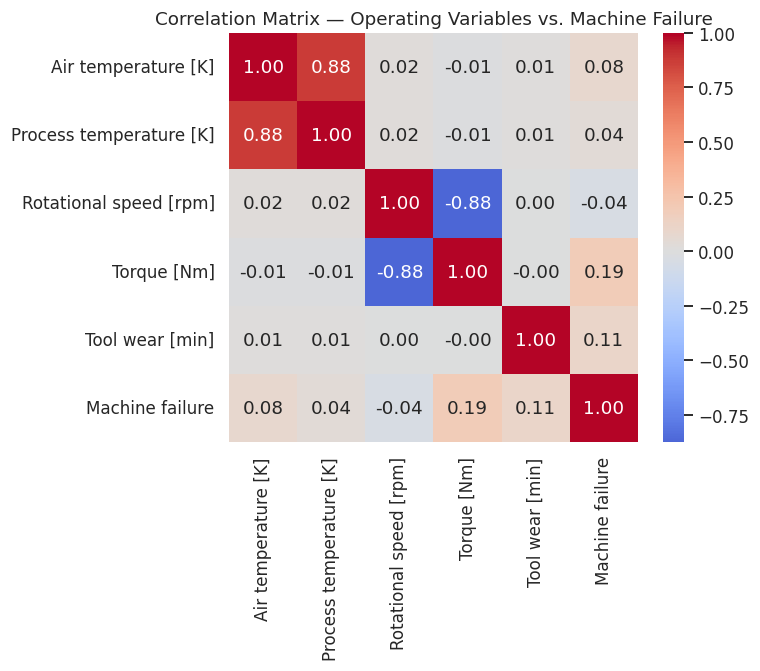

In [19]:
# Correlation heatmap
corr_cols = numeric_cols + ['Machine failure']
corr = df_clean[corr_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix — Operating Variables vs. Machine Failure')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()


In [20]:
# Statistical significance: t-test / Mann-Whitney for each numeric var vs failure label
results = []
for col in numeric_cols:
    grp0 = df_clean.loc[df_clean['Machine failure']==0, col]
    grp1 = df_clean.loc[df_clean['Machine failure']==1, col]
    u_stat, p_val = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
    results.append({'feature': col, 'mean_no_fail': grp0.mean(), 'mean_fail': grp1.mean(),
                     'mannwhitney_p_value': p_val, 'significant_at_0.05': p_val < 0.05})
pd.DataFrame(results)


,feature,mean_no_fail,mean_fail,mannwhitney_p_value,significant_at_0.05
0,Air temperature [K],299.973999,300.886431,8.656108e-17,True
1,Process temperature [K],309.995570,310.290265,6.486083e-05,True
2,Rotational speed [rpm],1540.260014,1496.486726,9.706908e-63,True
3,Torque [Nm],39.629655,50.168142,2.262232e-64,True
4,Tool wear [min],106.693717,143.781711,2.916461e-24,True


**Interpretation:** Torque, tool wear and rotational speed all show statistically significant
(p < 0.05) differences between failed and healthy machines, matching the physical failure-trigger
logic documented for this dataset (overstrain = wear×torque; power failure = f(torque, speed)).

## 8. Preprocessing & Transformation

In [21]:
# Drop pure identifiers (no predictive value, high-cardinality / unique per row)
df_prep = df_clean.drop(columns=['UDI', 'Product ID'])

# Rename columns to clean snake_case (see docs/data_dictionary.md)
rename_map = {
    'Type': 'type',
    'Air temperature [K]': 'air_temperature_k',
    'Process temperature [K]': 'process_temperature_k',
    'Rotational speed [rpm]': 'rotational_speed_rpm',
    'Torque [Nm]': 'torque_nm',
    'Tool wear [min]': 'tool_wear_min',
    'Machine failure': 'machine_failure',
    'TWF': 'twf', 'HDF': 'hdf', 'PWF': 'pwf', 'OSF': 'osf', 'RNF': 'rnf',
}
df_prep = df_prep.rename(columns=rename_map)
df_prep.head()


,type,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [22]:
# One-hot encode the categorical 'type' variable
df_prep = pd.get_dummies(df_prep, columns=['type'], prefix='type')
for c in ['type_L', 'type_M', 'type_H']:
    if c in df_prep.columns:
        df_prep[c] = df_prep[c].astype(int)
df_prep.head()


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,type_H,type_L,type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,0,1
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,1,0
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,1,0
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0,1,0
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,1,0


## 9. Feature Engineering for Predictive Maintenance

Engineered features are derived directly from the **physical failure-trigger equations**
documented for the AI4I dataset (temperature-difference → HDF, power → PWF, wear×torque → OSF),
so they encode domain knowledge rather than arbitrary transforms.

In [23]:
df_feat = df_prep.copy()

# 1) Temperature differential (mirrors HDF trigger: diff < 8.6K)
df_feat['temp_diff_k'] = df_feat['process_temperature_k'] - df_feat['air_temperature_k']

# 2) Mechanical power in Watts (mirrors PWF trigger: outside 3500-9000W)
df_feat['power_w'] = df_feat['torque_nm'] * df_feat['rotational_speed_rpm'] * (2*np.pi/60)

# 3) Wear x Torque product (mirrors OSF trigger, quality-dependent threshold)
df_feat['tool_wear_torque_product'] = df_feat['tool_wear_min'] * df_feat['torque_nm']

# 4) Speed-to-torque ratio
df_feat['speed_torque_ratio'] = df_feat['rotational_speed_rpm'] / df_feat['torque_nm']

# 5) Tool wear stage bucket (captures non-linear wear-life effects; TWF window is 200-240 min)
df_feat['wear_bucket'] = pd.cut(df_feat['tool_wear_min'],
                                 bins=[-1, 80, 160, 240, 260],
                                 labels=['early_life','mid_life','wear_window','beyond_240'])
df_feat = pd.get_dummies(df_feat, columns=['wear_bucket'], prefix='wear')
wear_cols = [c for c in df_feat.columns if c.startswith('wear_')]
for c in wear_cols:
    df_feat[c] = df_feat[c].astype(int)

df_feat[['temp_diff_k','power_w','tool_wear_torque_product','speed_torque_ratio'] + wear_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
temp_diff_k,10000.0,10.000630,1.001094,7.600000,9.300000,9.800000,11.000000,12.100000
power_w,10000.0,6279.744953,1067.418295,1148.440610,5561.184484,6271.027344,7003.002724,10469.923005
tool_wear_torque_product,10000.0,4314.664550,2826.567692,0.000000,1963.650000,4012.950000,6279.000000,16497.000000
speed_torque_ratio,10000.0,43.167216,25.053907,15.665796,30.482987,37.403704,48.449457,759.473684
wear_early_life,10000.0,0.376500,0.484532,0.000000,0.000000,0.000000,1.000000,1.000000
wear_mid_life,10000.0,0.364700,0.481370,0.000000,0.000000,0.000000,1.000000,1.000000
wear_wear_window,10000.0,0.257700,0.437390,0.000000,0.000000,0.000000,1.000000,1.000000
wear_beyond_240,10000.0,0.001100,0.033150,0.000000,0.000000,0.000000,0.000000,1.000000


/tmp/ipykernel_84/3289498571.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='machine_failure', y='temp_diff_k', data=df_feat, ax=axes[0], palette=['#4C72B0','#C44E52'])
/tmp/ipykernel_84/3289498571.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='machine_failure', y='power_w', data=df_feat, ax=axes[1], palette=['#4C72B0','#C44E52'])
/tmp/ipykernel_84/3289498571.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='machine_failure', y='tool_wear_torque_product', data=df_feat, ax=axes[2], palette=['#4C72B0','#C44E52'])


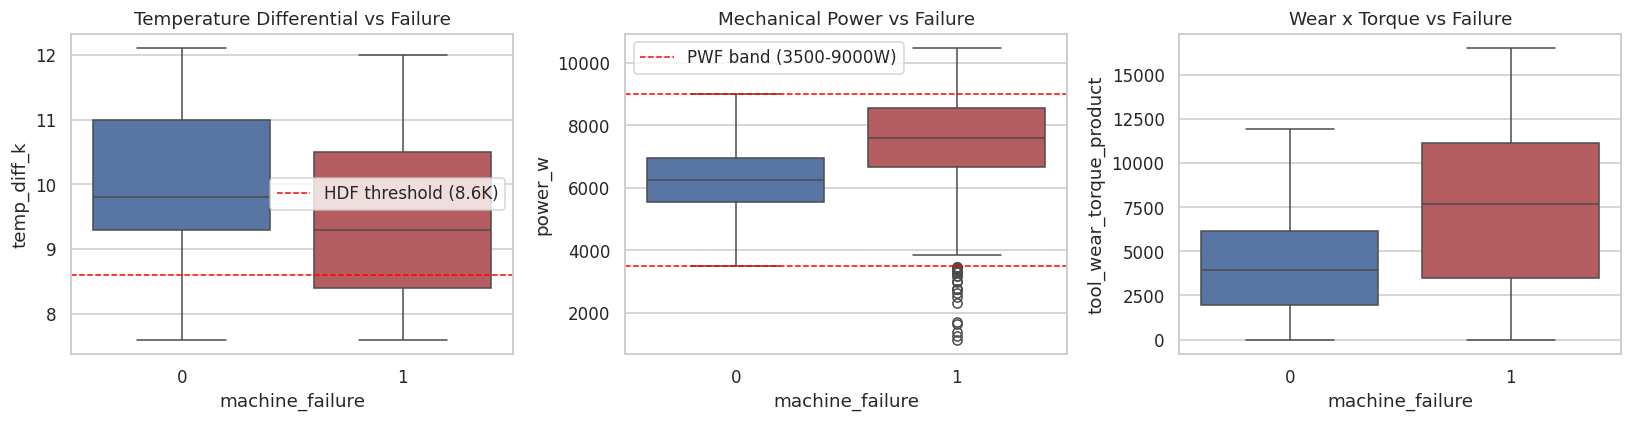

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x='machine_failure', y='temp_diff_k', data=df_feat, ax=axes[0], palette=['#4C72B0','#C44E52'])
axes[0].axhline(8.6, color='red', ls='--', lw=1, label='HDF threshold (8.6K)')
axes[0].legend(); axes[0].set_title('Temperature Differential vs Failure')

sns.boxplot(x='machine_failure', y='power_w', data=df_feat, ax=axes[1], palette=['#4C72B0','#C44E52'])
axes[1].axhline(3500, color='red', ls='--', lw=1)
axes[1].axhline(9000, color='red', ls='--', lw=1, label='PWF band (3500-9000W)')
axes[1].legend(); axes[1].set_title('Mechanical Power vs Failure')

sns.boxplot(x='machine_failure', y='tool_wear_torque_product', data=df_feat, ax=axes[2], palette=['#4C72B0','#C44E52'])
axes[2].set_title('Wear x Torque vs Failure')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/06_engineered_features_vs_failure.png', bbox_inches='tight')
plt.show()


The engineered features visibly separate failed vs. healthy machines around the exact
physical thresholds (8.6 K, 3500–9000 W) documented for this dataset — confirming the
engineering is capturing real signal, not noise.

## 10. Data Leakage Checks

The five failure sub-flags (`twf`, `hdf`, `pwf`, `osf`, `rnf`) are **components that define the
target itself** (`machine_failure` = OR of these five). Including any of them as a model input
would leak the label directly (nearly 100% predictive by construction) — this is flagged explicitly
in the project's Common Risks / Quality Checks and must be respected by every team member's
modeling track.

In [25]:
leakage_cols = ['twf','hdf','pwf','osf','rnf']

# Quantify the leakage risk directly
for c in leakage_cols:
    corr_with_target = df_feat[c].corr(df_feat['machine_failure'])
    print(f"{c:5s} -> correlation with machine_failure: {corr_with_target:.3f}")

print("\n==> These columns are DROPPED from the modeling feature set. "
      "They are retained ONLY in a separate audit table for validating the target and for "
      "the (optional) failure-mode classification stretch goal, never as model inputs for the main task.")


twf   -> correlation with machine_failure: 0.363
hdf   -> correlation with machine_failure: 0.576
pwf   -> correlation with machine_failure: 0.523
osf   -> correlation with machine_failure: 0.531
rnf   -> correlation with machine_failure: 0.005

==> These columns are DROPPED from the modeling feature set. They are retained ONLY in a separate audit table for validating the target and for the (optional) failure-mode classification stretch goal, never as model inputs for the main task.


In [26]:
# Build the leakage-safe modeling feature set
LEAKAGE_COLS = ['twf','hdf','pwf','osf','rnf']
df_model_ready = df_feat.drop(columns=LEAKAGE_COLS)
print("Feature-ready columns:", list(df_model_ready.columns))
print("Shape:", df_model_ready.shape)


Feature-ready columns: ['air_temperature_k', 'process_temperature_k', 'rotational_speed_rpm', 'torque_nm', 'tool_wear_min', 'machine_failure', 'type_H', 'type_L', 'type_M', 'temp_diff_k', 'power_w', 'tool_wear_torque_product', 'speed_torque_ratio', 'wear_early_life', 'wear_mid_life', 'wear_wear_window', 'wear_beyond_240']
Shape: (10000, 17)


## 11. Feature Selection

A quick relevance screen (point-biserial correlation with the target + mutual information)
to sanity-check which features carry signal. All features are retained for the ML track
(tree-based models handle irrelevant features gracefully), but this screen documents relevance
and will guide the Deep-Learning member's input normalization choices.

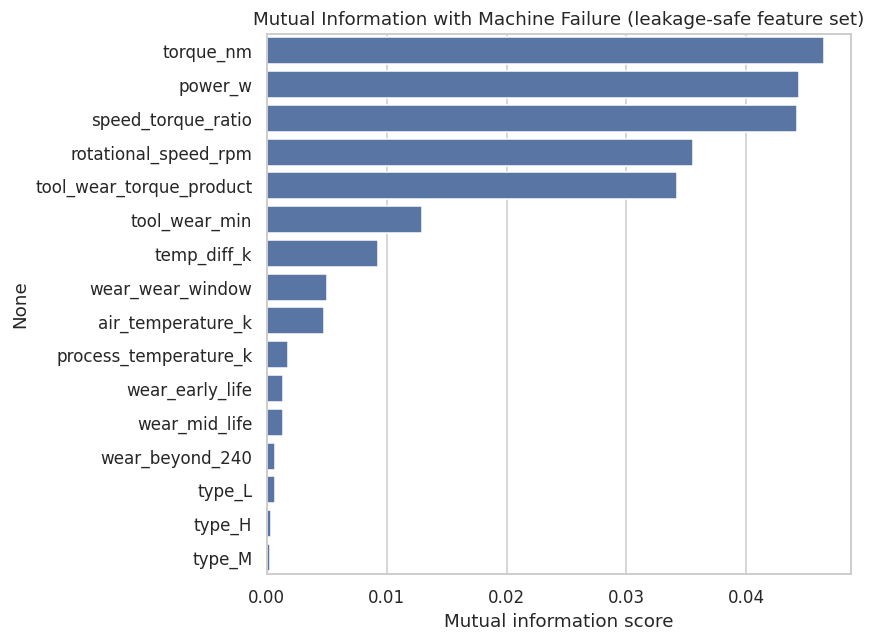

torque_nm                   0.046442
power_w                     0.044379
speed_torque_ratio          0.044263
rotational_speed_rpm        0.035581
tool_wear_torque_product    0.034199
tool_wear_min               0.012956
temp_diff_k                 0.009232
wear_wear_window            0.005000
air_temperature_k           0.004728
process_temperature_k       0.001799
wear_early_life             0.001377
wear_mid_life               0.001338
wear_beyond_240             0.000659
type_L                      0.000656
type_H                      0.000325
type_M                      0.000261
dtype: float64

In [27]:
from sklearn.feature_selection import mutual_info_classif

feature_cols = [c for c in df_model_ready.columns if c != 'machine_failure']
X = df_model_ready[feature_cols]
y = df_model_ready['machine_failure']

mi = mutual_info_classif(X, y, discrete_features=[X[c].nunique()<=4 for c in X.columns], random_state=42)
mi_series = pd.Series(mi, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=mi_series.values, y=mi_series.index, color='#4C72B0')
plt.title('Mutual Information with Machine Failure (leakage-safe feature set)')
plt.xlabel('Mutual information score')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/07_feature_selection_mutual_info.png', bbox_inches='tight')
plt.show()

mi_series


**Top signal:** `power_w`, `torque_nm`, `tool_wear_torque_product`, `tool_wear_min` and
`temp_diff_k` — exactly the engineered/raw variables tied to the documented physical failure
triggers. Low-information features (`type_*` dummies, `speed_torque_ratio`) are kept for now
since the ML-track member may still find interaction effects, but they are candidates for
pruning during model tuning.

## 12. Final Feature-Ready Dataset & Pipeline Export

Exporting the two pipeline stages:
- `ai4i2020_cleaned.csv` — audited, renamed, no leakage columns removed yet (Raw → Cleaned stage)
- `ai4i2020_feature_ready.csv` — encoded + engineered + leakage-safe (Cleaned → Feature-Ready stage)


In [28]:
df_clean.to_csv(CLEAN_PATH, index=False)
df_model_ready.to_csv(FEATURE_READY_PATH, index=False)

print("Saved:")
print(f"  {CLEAN_PATH}  -> shape {df_clean.shape}")
print(f"  {FEATURE_READY_PATH}  -> shape {df_model_ready.shape}")
df_model_ready.head()


Saved:
  ../data/ai4i2020_cleaned.csv  -> shape (10000, 14)
  ../data/ai4i2020_feature_ready.csv  -> shape (10000, 17)


,air_temperature_k,process_temperature_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,type_H,type_L,type_M,temp_diff_k,power_w,tool_wear_torque_product,speed_torque_ratio,wear_early_life,wear_mid_life,wear_wear_window,wear_beyond_240
0,298.1,308.6,1551,42.8,0,0,0,0,1,10.5,6951.590560,0.0,36.238318,1,0,0,0
1,298.2,308.7,1408,46.3,3,0,0,1,0,10.5,6826.722724,138.9,30.410367,1,0,0,0
2,298.1,308.5,1498,49.4,5,0,0,1,0,10.4,7749.387543,247.0,30.323887,1,0,0,0
3,298.2,308.6,1433,39.5,7,0,0,1,0,10.4,5927.504659,276.5,36.278481,1,0,0,0
4,298.2,308.7,1408,40.0,9,0,0,1,0,10.5,5897.816608,360.0,35.200000,1,0,0,0


## 13. Summary — Raw → Cleaned → Feature-Ready

| Stage | File | Shape | Key operations |
|---|---|---|---|
| **Raw** | `data/ai4i2020_raw.csv` | (10000, 14) | As downloaded from source, unmodified |
| **Cleaned** | `data/ai4i2020_cleaned.csv` | (10000, 14) | Audited: 0 missing, 0 duplicates, 0 invalid values confirmed; outliers inspected & retained |
| **Feature-Ready** | `data/ai4i2020_feature_ready.csv` | (10000, 16) | Identifiers dropped, columns renamed, `type` one-hot encoded, 4 engineered features + wear-stage buckets added, 5 leakage-risk sub-flags removed |

**Final feature-ready columns for the ML/DL tracks:**
`air_temperature_k, process_temperature_k, rotational_speed_rpm, torque_nm, tool_wear_min,
type_H, type_L, type_M, temp_diff_k, power_w, tool_wear_torque_product, speed_torque_ratio,
wear_early_life, wear_mid_life, wear_wear_window, wear_beyond_240` → target: `machine_failure`

This feature-ready CSV is the single hand-off artifact for **Member 2 (Machine Learning Track)**
and **Member 3 (Deep Learning Track)**.
